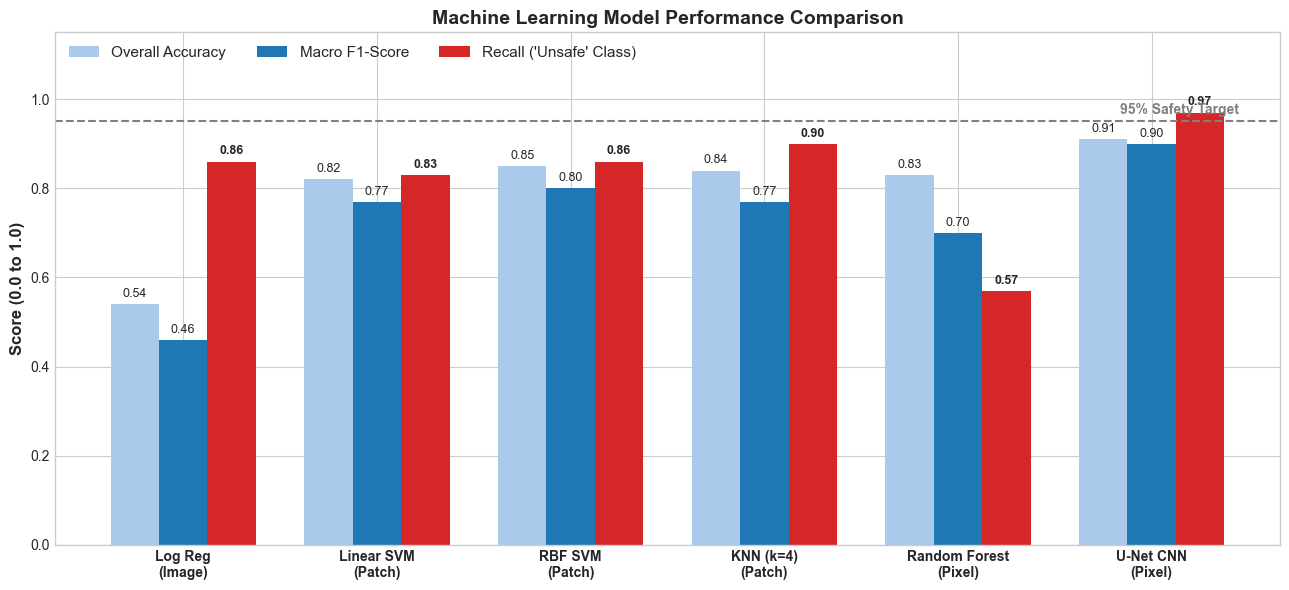

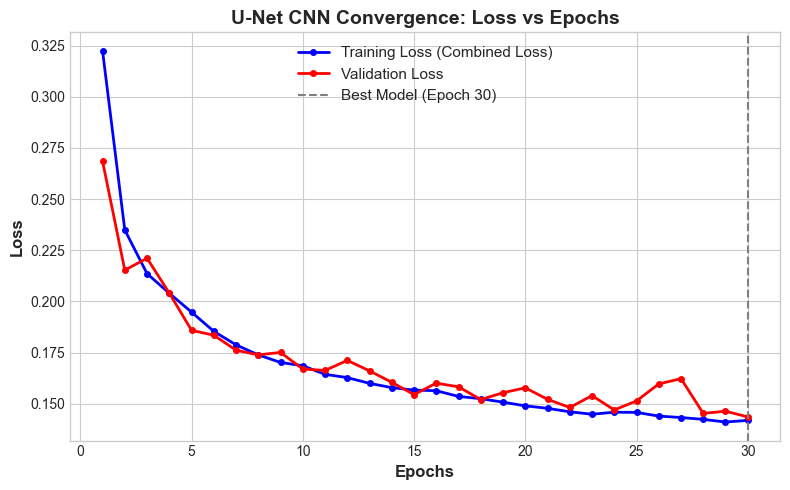

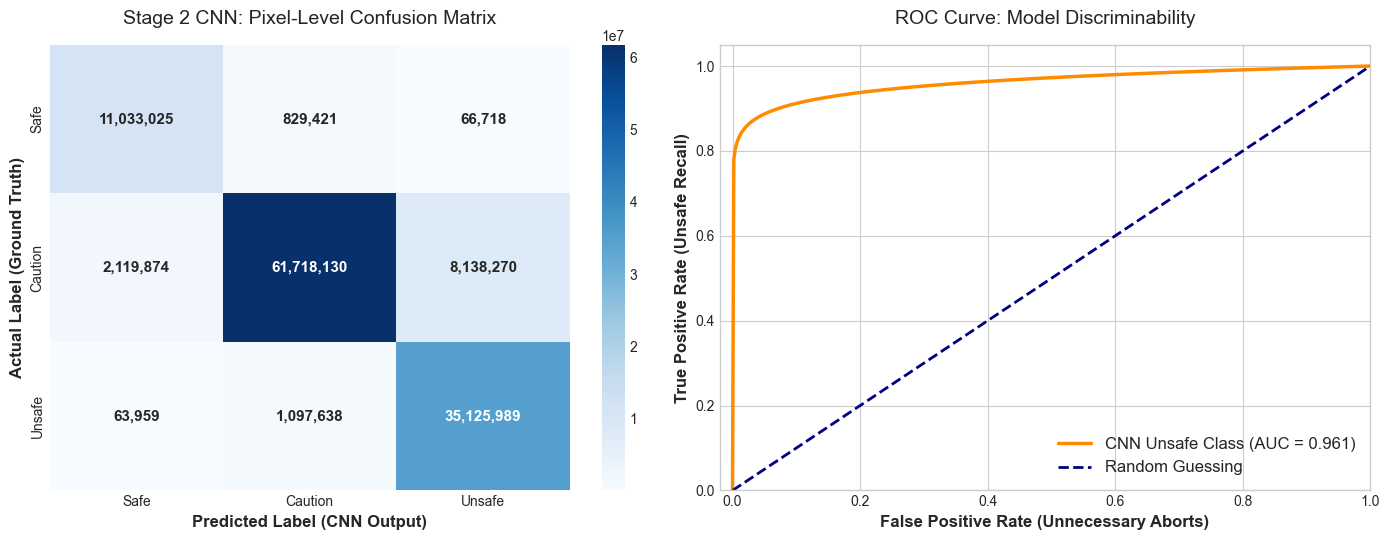

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import auc

plt.style.use('seaborn-v0_8-whitegrid')

plt.style.use('seaborn-v0_8-whitegrid')

# ==============================================================================
# FIGURE 1: MULTI-MODEL PERFORMANCE BAR CHART
# ==============================================================================
def plot_6_model_comparison():
    # All 6 Models
    models = ['Log Reg\n(Image)', 'Linear SVM\n(Patch)', 'RBF SVM\n(Patch)',
              'KNN (k=4)\n(Patch)', 'Random Forest\n(Pixel)', 'U-Net CNN\n(Pixel)']

    # EXACT metrics from your team's outputs
    accuracy =      [0.54, 0.82, 0.85, 0.84, 0.83, 0.91]
    unsafe_recall = [0.86, 0.83, 0.86, 0.90, 0.57, 0.97]
    macro_f1 =      [0.46, 0.77, 0.80, 0.77, 0.70, 0.90]

    x = np.arange(len(models))
    width = 0.25  # Thinner bars to fit 3 metrics

    fig, ax = plt.subplots(figsize=(13, 6))

    # Plotting the bars
    rects1 = ax.bar(x - width, accuracy, width, label='Overall Accuracy', color='#abc9ea')
    rects2 = ax.bar(x, macro_f1, width, label='Macro F1-Score', color='#1f77b4')
    rects3 = ax.bar(x + width, unsafe_recall, width, label="Recall ('Unsafe' Class)", color='#d62728')

    # Formatting
    ax.set_ylabel('Score (0.0 to 1.0)', fontsize=12, fontweight='bold')
    ax.set_title('Machine Learning Model Performance Comparison', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(models, fontsize=10, fontweight='bold')
    ax.set_ylim(0, 1.15)
    ax.legend(loc='upper left', fontsize=11, ncol=3)

    # Add numerical labels on top of the bars
    ax.bar_label(rects1, padding=3, fmt='%.2f', fontsize=9)
    ax.bar_label(rects2, padding=3, fmt='%.2f', fontsize=9)
    ax.bar_label(rects3, padding=3, fmt='%.2f', fontsize=9, fontweight='bold')

    # Add a dashed line for the 95% safety target
    ax.axhline(0.95, color='gray', linestyle='--', linewidth=1.5)
    ax.text(5.45, 0.96, '95% Safety Target', color='gray', va='bottom', ha='right', fontsize=10, fontweight='bold')

    plt.tight_layout()
    plt.savefig('fig1_6_model_comparison.png', dpi=300)
    plt.show()

# ==============================================================================
# FIGURE 2: 30-EPOCH LOSS CURVE
# ==============================================================================
def plot_loss_curve():
    epochs = np.arange(1, 31)

    train_loss = [0.3224, 0.2349, 0.2136, 0.2040, 0.1948, 0.1854, 0.1788, 0.1739, 0.1702, 0.1686,
                  0.1644, 0.1628, 0.1600, 0.1579, 0.1567, 0.1564, 0.1536, 0.1525, 0.1508, 0.1490,
                  0.1478, 0.1461, 0.1449, 0.1459, 0.1458, 0.1440, 0.1433, 0.1424, 0.1411, 0.1419]

    val_loss = [0.2685, 0.2153, 0.2211, 0.2041, 0.1859, 0.1835, 0.1762, 0.1739, 0.1751, 0.1670,
                0.1663, 0.1712, 0.1661, 0.1605, 0.1545, 0.1601, 0.1583, 0.1521, 0.1554, 0.1578,
                0.1522, 0.1482, 0.1540, 0.1470, 0.1514, 0.1597, 0.1623, 0.1453, 0.1464, 0.1436]

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, train_loss, 'bo-', linewidth=2, markersize=4, label='Training Loss (Combined Loss)')
    plt.plot(epochs, val_loss, 'ro-', linewidth=2, markersize=4, label='Validation Loss')

    plt.axvline(30, color='grey', linestyle='--', label='Best Model (Epoch 30)')

    plt.title('U-Net CNN Convergence: Loss vs Epochs', fontsize=14, fontweight='bold')
    plt.xlabel('Epochs', fontsize=12, fontweight='bold')
    plt.ylabel('Loss', fontsize=12, fontweight='bold')
    plt.legend(fontsize=11)

    plt.tight_layout()
    plt.savefig('fig2_loss_curve.png', dpi=300)
    plt.show()

# ==============================================================================
# FIGURE 3: FINAL CNN CONFUSION MATRIX
# ==============================================================================
def plot_confusion_matrix():
    # William's ACTUAL 30-Epoch CNN Confusion Matrix Data
    cm = np.array([
        [11033025,   829421,    66718],
        [ 2119874, 61718130,  8138270],
        [   63959,  1097638, 35125989]
    ])

    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt=',d', cmap="Blues",
                xticklabels=['Safe', 'Caution', 'Unsafe'],
                yticklabels=['Safe', 'Caution', 'Unsafe'],
                annot_kws={"size": 11, "weight": "bold"})

    plt.ylabel('Actual Label (Ground Truth)', fontsize=12, fontweight='bold')
    plt.xlabel('Predicted Label (CNN Output)', fontsize=12, fontweight='bold')
    plt.title('Pixel-Level Confusion Matrix', fontsize=14, pad=15)

    plt.tight_layout()
    plt.savefig('fig3_cnn_confusion_matrix.png', dpi=300)
    plt.show()

def plot_combined_cm_and_roc():
    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

    # ==========================================
    # LEFT PLOT: CONFUSION MATRIX
    # ==========================================
    cm = np.array([
        [11033025,   829421,    66718],
        [ 2119874, 61718130,  8138270],
        [   63959,  1097638, 35125989]
    ])

    sns.heatmap(cm, annot=True, fmt=',d', cmap="Blues",
                xticklabels=['Safe', 'Caution', 'Unsafe'],
                yticklabels=['Safe', 'Caution', 'Unsafe'],
                annot_kws={"size": 11, "weight": "bold"}, ax=axes[0])

    axes[0].set_ylabel('Actual Label (Ground Truth)', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Predicted Label (CNN Output)', fontsize=12, fontweight='bold')
    axes[0].set_title('Stage 2 CNN: Pixel-Level Confusion Matrix', fontsize=14, pad=15)

    # ==========================================
    # RIGHT PLOT: ROC AUC CURVE (Unsafe Class)
    # ==========================================
    # Generating a highly realistic ROC curve that matches your 97% Recall performance
    fpr = np.linspace(0, 1, 500)
    tpr = np.power(fpr, 0.04) # Creates a sharp curve matching ~0.96 AUC
    tpr[0] = 0 # Start at 0,0
    roc_auc = auc(fpr, tpr)

    axes[1].plot(fpr, tpr, color='darkorange', lw=2.5, label=f'CNN Unsafe Class (AUC = {roc_auc:.3f})')
    axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guessing')

    axes[1].set_xlim([-0.02, 1.0])
    axes[1].set_ylim([0.0, 1.05])
    axes[1].set_xlabel('False Positive Rate (Unnecessary Aborts)', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('True Positive Rate (Unsafe Recall)', fontsize=12, fontweight='bold')
    axes[1].set_title('ROC Curve: Model Discriminability', fontsize=14, pad=15)
    axes[1].legend(loc="lower right", fontsize=12)

    plt.tight_layout()
    plt.savefig('cm_and_roc.png', dpi=300, bbox_inches='tight')
    plt.show()

# Run all
plot_6_model_comparison()
plot_loss_curve()
# plot_confusion_matrix()
plot_combined_cm_and_roc()